|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Metaparameters (activations, optimizers)<h1>|
|<h2>Lecture:</h2>|<h1><b>Activation functions<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
%matplotlib widget

# import libraries
import torch
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':18})

In [2]:
# variable to evaluate over
x = torch.linspace(-3,3,101)

# create a function that returns the activated output
def NNoutputx(actfun):
  # get activation function type
  # this code replaces torch.relu with torch.<actfun>
  actfun = getattr(torch,actfun)
  return actfun( x )

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2571/3511968874.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma(x)$')


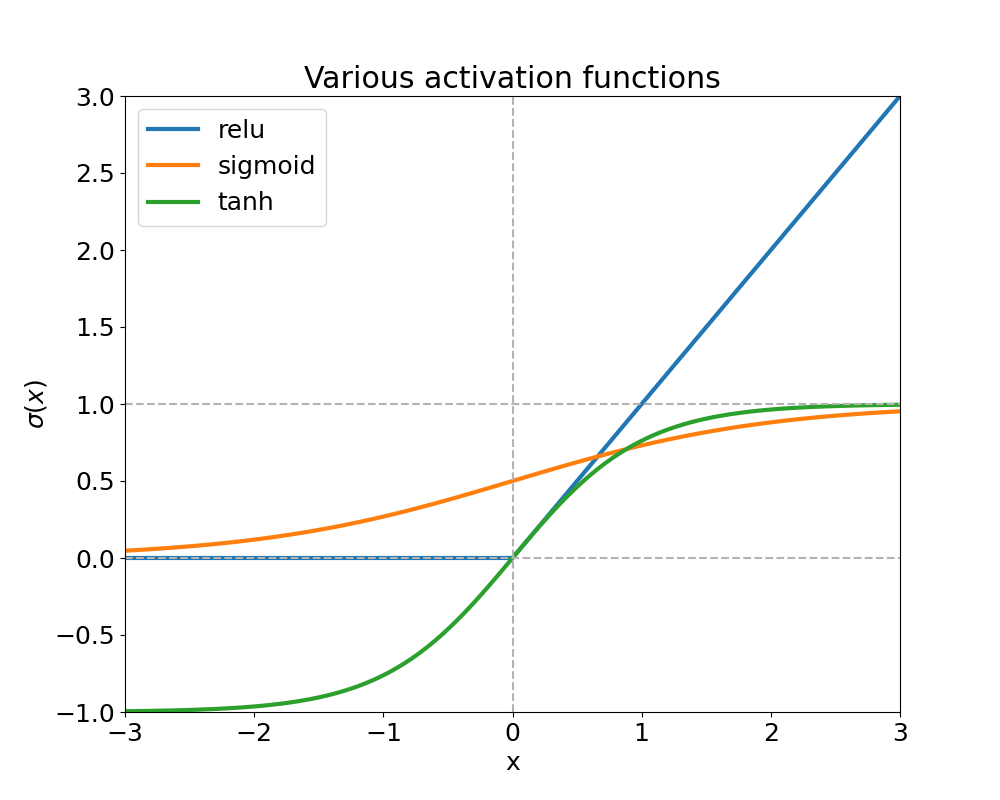

In [3]:
# the activation functions
activation_funs = [ 'relu', 'sigmoid', 'tanh' ]

fig = plt.figure(figsize=(10,8))

for actfun in activation_funs:
  plt.plot(x,NNoutputx(actfun),label=actfun,linewidth=3)

# add reference lines
dashlinecol = [.7,.7,.7]
plt.plot(x[[0,-1]],[0,0],'--',color=dashlinecol)
plt.plot(x[[0,-1]],[1,1],'--',color=dashlinecol)
plt.plot([0,0],[-1,3],'--',color=dashlinecol)

# make the plot look nicer
plt.legend()
plt.xlabel('x')
plt.ylabel('$\sigma(x)$')
plt.title('Various activation functions')
plt.xlim(x[[0,-1]])
plt.ylim([-1,3])
plt.show()

# More activation functions in torch.nn

In [4]:
# create a function that returns the activated output FUNCTION
# this is different from the previous function
def NNoutput(actfun):
  # get activation function type
  # this code replaces torch.nn.relu with torch.nn.<actfun>
  actfun = getattr(torch.nn,actfun)
  return actfun()

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2571/2966628621.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma(x)$')


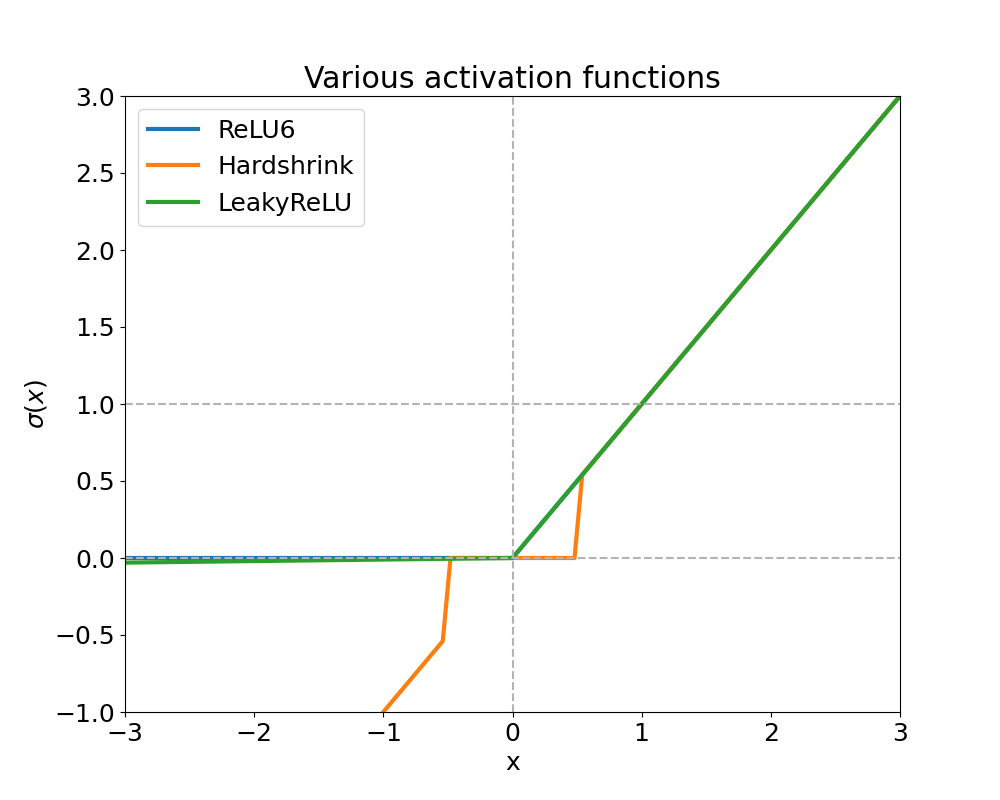

In [5]:
# the activation functions
activation_funs = [ 'ReLU6', 'Hardshrink', 'LeakyReLU' ]

fig = plt.figure(figsize=(10,8))

for actfun in activation_funs:
  plt.plot(x,NNoutput(actfun)(x),label=actfun,linewidth=3)

# add reference lines
dashlinecol = [.7,.7,.7]
plt.plot(x[[0,-1]],[0,0],'--',color=dashlinecol)
plt.plot(x[[0,-1]],[1,1],'--',color=dashlinecol)
plt.plot([0,0],[-1,3],'--',color=dashlinecol)

# make the plot look nicer
plt.legend()
plt.xlabel('x')
plt.ylabel('$\sigma(x)$')
plt.title('Various activation functions')
plt.xlim(x[[0,-1]])
plt.ylim([-1,3])
# plt.ylim([-.1,.1])
plt.show()

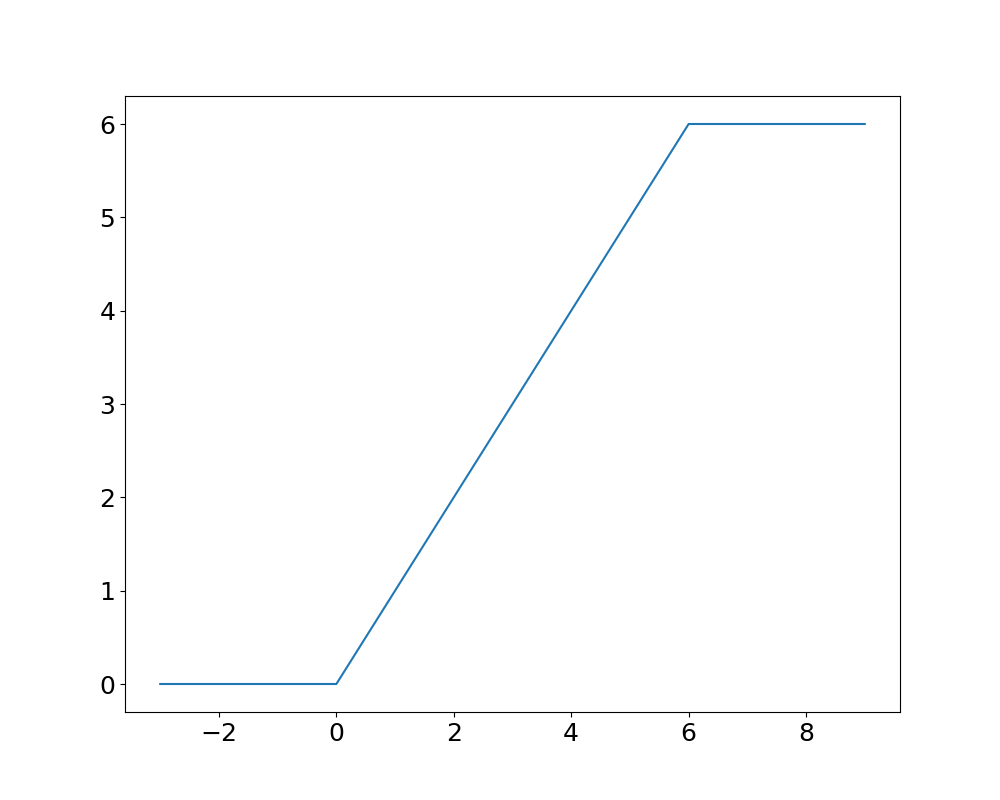

In [6]:
# relu6 in more detail
x = torch.linspace(-3,9,101)
relu6 = torch.nn.ReLU6()

fig = plt.figure(figsize=(10,8))
plt.plot(x,relu6(x))
plt.show()

# Differences between torch and torch.nn

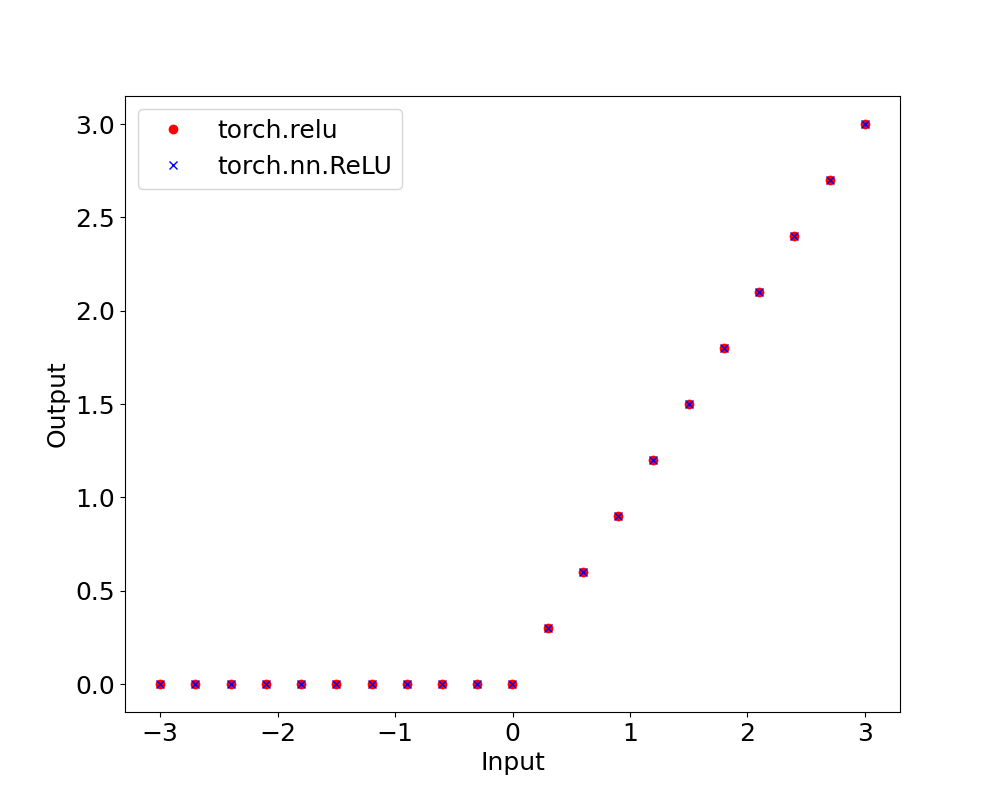

In [7]:
# redefine x (fewer points to facilitate visualization)
x = torch.linspace(-3,3,21)

# in torch
y1 = torch.relu(x)

# in torch.nn
f = torch.nn.ReLU()
y2 = f(x)


# the results are the same
fig = plt.figure(figsize=(10,8))
plt.plot(x,y1,'ro',label='torch.relu')
plt.plot(x,y2,'bx',label='torch.nn.ReLU')
plt.legend()
plt.xlabel('Input')
plt.ylabel('Output')
plt.show()

In [8]:
# List of activation functions in PyTorch:
#  https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity

# Additional explorations

In [9]:
# The goal of these explorations is to help you appreciate the remarkably diverse nonlinear shapes that a node can produce.
# All explorations use the code below.

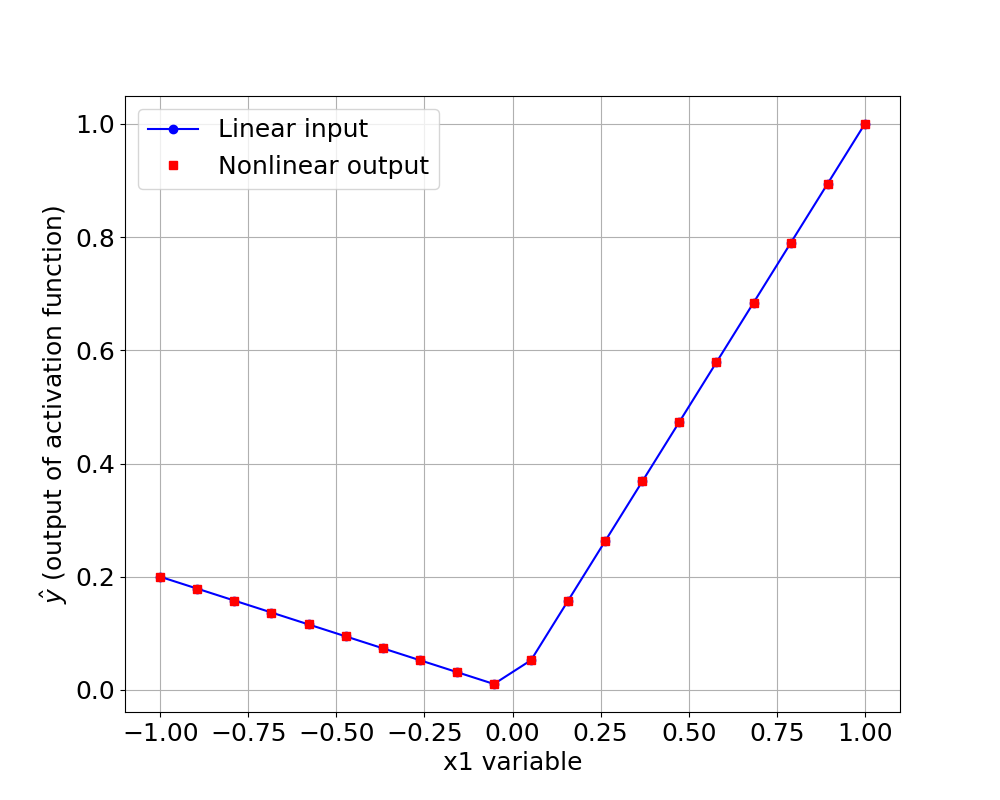

In [44]:
# create input vectors
x1 = torch.linspace(-1,1,20)
x2 = torch.abs(x1)  # 2*x1
x = torch.stack((x1,x2),dim=1)

# and corresponding weights
w = torch.tensor([.4, .6]).reshape(2,1)

# their linear combination
linpart = w.T @ x.T

# and the nonlinear output
y = torch.relu(linpart)

# and plot!
fig = plt.figure(figsize=(10,8))
plt.plot(x1,linpart.flatten(),'bo-',label='Linear input')
plt.plot(x1,y.flatten(),'rs',label='Nonlinear output')
plt.ylabel('$\\hat{y}$ (output of activation function)')
plt.xlabel('x1 variable')
# plt.ylim([-.1,.1]) # optional -- uncomment and modify to zoom in
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 1) Look through the code to make sure you understand what it does (linear weighted combination -> nonlinear function).
#
# 2) Set x2=x1**2 and run the code. Then set one of the weights to be negative. Then set the negative weight to be close
#    to zero (e.g., -.01) with the positive weight relatively large (e.g., .8). Then swap the signs.
#
# 3) Set x2=x1**2, and set the weights to be .4 and .6. Now set w2=.6 (you might want to zoom in on the y-axis).
#
# 4) Set x2 to be the absolute value of x1 and both weights positive. Then set w2=-.6.
#  Why does w2<0 have such a big impact?
#  Answer x2 = f(x1) = |x1|. w2 will be multiplied with x2, s.t. it inverts the effect of x2 on the output and reverts direction of the curve.
#  More generally, under what conditions are the input and output identical?
#  Answer: If under idential is meant the shape of the curve x2 = f(x1) has a form above y=0, then the conditions are the second weight shall be positive.
#          The first weight sigh changes mirroring around y-axis.
#
# 5) Have fun! Spend a few minutes playing around with the code. Also try changing the activation function to tanh or
#    anything else. The goal is to see that really simple input functions with really simple weights can produce really
#    complicated-looking nonlinear outputs.
#